# Smart Grocery Planner — Ingredient Transformer




## Import & Konfigurasi

In [ ]:
import ast
import csv
import json
import math
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')

# ── Path ─────────────────────────────────────────────────────
ROOT          = Path('..') if Path('../data').exists() else Path('.')
CSV_PATH      = ROOT / 'data' / 'resep_bersih_clustered_new.csv'
VOCAB_PATH    = ROOT / 'data' / 'ingredient_vocab.json'
RECIPE_PATH   = ROOT / 'data' / 'recipes.json'
MODELS_DIR    = ROOT / 'artifacts' / 'models'
LOGS_DIR      = ROOT / 'artifacts' / 'logs'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameter ───────────────────────────────────────────
# 0 = gunakan semua data valid
MAX_RECIPES        = 0
MAX_VOCAB          = 0
MIN_MINUTES        = 0
MAX_MINUTES        = 0

MAX_SEQ_LEN        = 20
PAD_ID             = 0
SAMPLES_PER_RECIPE = 8

EMBED_DIM    = 64
NUM_HEADS    = 4
FFN_DIM      = 128
NUM_BLOCKS   = 2
DROPOUT_RATE = 0.1

BATCH_SIZE     = 64
EPOCHS         = 20
EARLY_PATIENCE = 5
LR             = 1e-3
MSE_WEIGHT     = 0.6
RANK_WEIGHT    = 0.4
MARGIN         = 0.05
SEED           = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f'Root       : {ROOT.resolve()}')
print(f'CSV exists : {CSV_PATH.exists()}')

TensorFlow : 2.21.0
NumPy      : 1.26.4
Root       : D:\kuliah\STUDI INDEPENDEN\Capstone\GIT\AI-ENGINEER
CSV exists : True



## Build Data dari CSV

In [2]:
def safe_list(raw: str) -> List[str]:
    if not raw:
        return []
    try:
        v = ast.literal_eval(raw)
        if isinstance(v, list):
            vals = [str(x).strip().lower() for x in v]
            return [x for x in vals if x]
    except Exception:
        pass

    # fallback untuk format "ing1, ing2, ing3"
    vals = [x.strip().lower() for x in str(raw).split(',')]
    return [x for x in vals if x]


def safe_minutes(raw: str) -> int | None:
    try:
        return int(float(raw))
    except (TypeError, ValueError):
        return None


def safe_calories(raw: str) -> int:
    try:
        return max(0, int(float(raw)))
    except (TypeError, ValueError):
        return 0


def parse_calories_from_nutrition(raw: str) -> int:
    try:
        v = ast.literal_eval(raw)
        return max(0, int(float(v[0]))) if isinstance(v, list) and v else 0
    except Exception:
        return 0


def pick_ingredients_column(row: Dict[str, str]) -> str:
    return str(row.get('ingredients_list') or row.get('ingredients') or '')


def pick_calories(row: Dict[str, str]) -> int:
    raw_cal = row.get('calories')
    if raw_cal not in (None, ''):
        return safe_calories(raw_cal)
    return parse_calories_from_nutrition(row.get('nutrition', ''))


def build_data(
    csv_path: Path,
    max_recipes: int,
    max_vocab: int,
    min_minutes: int,
    max_minutes: int,
) -> Tuple[List[dict], List[dict]]:
    print(f'Membaca {csv_path.name} ...')

    recipe_limit = max_recipes if max_recipes > 0 else None
    vocab_limit = max_vocab if max_vocab > 0 else None
    minute_upper = max_minutes if max_minutes > 0 else None

    raw_rows: List[dict] = []
    skipped_minutes = 0
    skipped_ingredients = 0

    with open(csv_path, encoding='utf-8', errors='replace', newline='') as f:
        for row in csv.DictReader(f):
            mins = safe_minutes(row.get('minutes', 0))
            if mins is None:
                skipped_minutes += 1
                continue
            if mins < min_minutes:
                continue
            if minute_upper is not None and mins > minute_upper:
                continue

            ings = safe_list(pick_ingredients_column(row))
            if len(ings) < 2:
                skipped_ingredients += 1
                continue

            raw_rows.append({
                'id':      str(row.get('id', '')).strip(),
                'name':    str(row.get('name', '')).strip().title(),
                'minutes': mins,
                'calories': pick_calories(row),
                'ingredients': ings,
                'cluster': str(row.get('cluster', '')).strip(),
                'cluster_label': str(row.get('cluster_label', '')).strip(),
            })

            if recipe_limit is not None and len(raw_rows) >= recipe_limit:
                break

    print(f'  Kandidat baris valid : {len(raw_rows):,}')
    print(f'  Skip minutes invalid : {skipped_minutes:,}')
    print(f'  Skip ingredients <2  : {skipped_ingredients:,}')

    counter: Counter = Counter()
    for r in raw_rows:
        counter.update(r['ingredients'])

    if vocab_limit is None:
        top_ings = [name for name, _ in counter.most_common()]
    else:
        top_ings = [name for name, _ in counter.most_common(vocab_limit)]

    # ID: 0=PAD, 1=UNK, 2.. = ingredients
    vocab_list = [
        {'ingredient_id': 0, 'ingredient_name': 'PAD'},
        {'ingredient_id': 1, 'ingredient_name': 'UNK'},
    ]
    name_to_id: Dict[str, int] = {'PAD': 0, 'UNK': 1}
    for idx, name in enumerate(top_ings, start=2):
        vocab_list.append({'ingredient_id': idx, 'ingredient_name': name})
        name_to_id[name] = idx

    recipe_list: List[dict] = []
    for r in raw_rows:
        ids = list(dict.fromkeys(name_to_id.get(ing, 1) for ing in r['ingredients']))
        recipe_list.append({
            'recipe_id':      r['id'],
            'recipe_name':    r['name'],
            'ingredient_ids': ids,
            'minutes':        r['minutes'],
            'calories':       r['calories'],
            'cluster':        r['cluster'],
            'cluster_label':  r['cluster_label'],
        })

        if recipe_limit is not None and len(recipe_list) >= recipe_limit:
            break

    print(f'  Vocab size          : {len(vocab_list):,}')
    print(f'  Resep output        : {len(recipe_list):,}')
    return vocab_list, recipe_list


if VOCAB_PATH.exists() and RECIPE_PATH.exists():
    vocab_list = json.loads(VOCAB_PATH.read_text(encoding='utf-8'))
    recipe_list = json.loads(RECIPE_PATH.read_text(encoding='utf-8'))

    should_rebuild = False
    if not vocab_list or vocab_list[0]['ingredient_name'] not in ('PAD', 'unk', 'UNK'):
        print('Vocab lama/invalid terdeteksi, rebuild dari CSV...')
        should_rebuild = True

    # Saat MAX_RECIPES=0, targetnya semua resep valid dari clustered (~200k+)
    if MAX_RECIPES > 0:
        if len(recipe_list) < MAX_RECIPES:
            print(f'Data resep di disk {len(recipe_list):,} < target {MAX_RECIPES:,}, rebuild dari CSV...')
            should_rebuild = True
    else:
        if CSV_PATH.name == 'resep_bersih_clustered.csv' and len(recipe_list) < 200_000:
            print('Data resep di disk belum full clustered, rebuild dari CSV...')
            should_rebuild = True

    if should_rebuild:
        vocab_list, recipe_list = build_data(
            CSV_PATH,
            max_recipes=MAX_RECIPES,
            max_vocab=MAX_VOCAB,
            min_minutes=MIN_MINUTES,
            max_minutes=MAX_MINUTES,
        )
    else:
        if MAX_RECIPES > 0 and len(recipe_list) > MAX_RECIPES:
            recipe_list = recipe_list[:MAX_RECIPES]
        print(f'Data dari disk: {len(vocab_list):,} vocab, {len(recipe_list):,} resep')
else:
    vocab_list, recipe_list = build_data(
        CSV_PATH,
        max_recipes=MAX_RECIPES,
        max_vocab=MAX_VOCAB,
        min_minutes=MIN_MINUTES,
        max_minutes=MAX_MINUTES,
    )

VOCAB_PATH.write_text(json.dumps(vocab_list, indent=2, ensure_ascii=False), encoding='utf-8')
RECIPE_PATH.write_text(json.dumps(recipe_list, indent=2, ensure_ascii=False), encoding='utf-8')

VOCAB_SIZE_WITH_PAD = len(vocab_list)
name_to_id: Dict[str, int] = {v['ingredient_name']: v['ingredient_id'] for v in vocab_list}
id_to_name: Dict[int, str] = {v['ingredient_id']: v['ingredient_name'] for v in vocab_list}

print(f'VOCAB_SIZE_WITH_PAD = {VOCAB_SIZE_WITH_PAD:,}')

Data dari disk: 14,484 vocab, 213,614 resep
VOCAB_SIZE_WITH_PAD = 14,484



## EDA Singkat

=== Dataset Summary ===
  Total resep            : 213,614
  Vocab size (incl. PAD) : 14484
  Bahan/resep (median)   : 9
  Bahan/resep (max)      : 43
  MAX_SEQ_LEN setting    : 20
  Resep akan di-truncate : 0.7%

  Top 10 bahan:
    #  2  butter
    #  3  sugar
    #  4  onion
    #  5  water
    #  6  olive oil
    #  7  eggs
    #  8  flour
    #  9  milk
    # 10  garlic cloves
    # 11  pepper


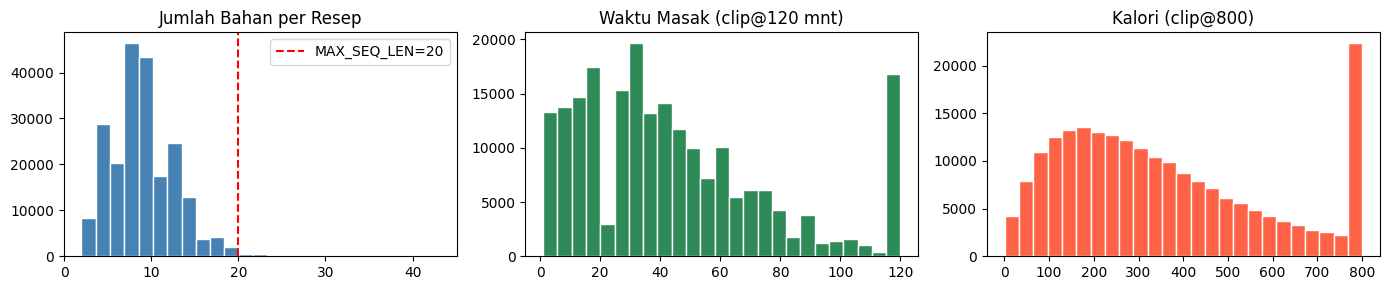

In [3]:
n_ings  = [len(r['ingredient_ids']) for r in recipe_list]
minutes = [r['minutes']  for r in recipe_list]
cals    = [r['calories'] for r in recipe_list]

print('=== Dataset Summary ===')
print(f'  Total resep            : {len(recipe_list):,}')
print(f'  Vocab size (incl. PAD) : {VOCAB_SIZE_WITH_PAD}')
print(f'  Bahan/resep (median)   : {int(np.median(n_ings))}')
print(f'  Bahan/resep (max)      : {max(n_ings)}')
print(f'  MAX_SEQ_LEN setting    : {MAX_SEQ_LEN}')
pct = sum(1 for n in n_ings if n > MAX_SEQ_LEN) / len(n_ings) * 100
print(f'  Resep akan di-truncate : {pct:.1f}%')

print(f'\n  Top 10 bahan:')
for v in vocab_list[2:12]:
    print(f"    #{v['ingredient_id']:3d}  {v['ingredient_name']}")

fig, ax = plt.subplots(1, 3, figsize=(14, 3))
ax[0].hist(n_ings, bins=25, color='steelblue', edgecolor='white')
ax[0].axvline(MAX_SEQ_LEN, color='red', linestyle='--', label=f'MAX_SEQ_LEN={MAX_SEQ_LEN}')
ax[0].set_title('Jumlah Bahan per Resep'); ax[0].legend()
ax[1].hist([min(m,120) for m in minutes], bins=25, color='seagreen', edgecolor='white')
ax[1].set_title('Waktu Masak (clip@120 mnt)')
ax[2].hist([min(c,800) for c in cals if c>0], bins=25, color='tomato', edgecolor='white')
ax[2].set_title('Kalori (clip@800)')
plt.tight_layout(); plt.show()


## Data Contracts & Sequence Preprocessing

In [4]:
@dataclass(frozen=True)
class RecipeRecord:
    recipe_id:      str
    recipe_name:    str
    ingredient_ids: List[int]
    minutes:        int
    calories:       int

@dataclass(frozen=True)
class TrainingSample:
    user_ingredient_ids:   List[int]
    recipe_ingredient_ids: List[int]
    coverage_target:       float


def load_recipes(path: Path) -> List[RecipeRecord]:
    return [
        RecipeRecord(
            recipe_id      = str(x['recipe_id']),
            recipe_name    = str(x['recipe_name']),
            ingredient_ids = [int(i) for i in x['ingredient_ids']],
            minutes        = int(x.get('minutes', 30)),
            calories       = int(x.get('calories', 300)),
        )
        for x in json.loads(path.read_text(encoding='utf-8'))
    ]


def compute_coverage_score(user_ids: Iterable[int], recipe_ids: Iterable[int]) -> float:
    rset = set(recipe_ids)
    return float(len(set(user_ids) & rset) / len(rset)) if rset else 0.0


def generate_samples(
    recipes: List[RecipeRecord],
    vocab_size: int,
    samples_per_recipe: int = 8,
    seed: int = 42,
) -> List[TrainingSample]:
    rng     = random.Random(seed)
    all_ids = list(range(2, vocab_size))
    samples = []
    for rec in recipes:
        pool = [i for i in rec.ingredient_ids if i >= 2]
        for _ in range(samples_per_recipe):
            kept     = [i for i in pool if rng.random() > 0.35]
            noise    = rng.sample(all_ids, k=rng.randint(0, 2))
            user_ids = list(set(kept + noise))
            cov      = compute_coverage_score(user_ids, rec.ingredient_ids)
            samples.append(TrainingSample(
                user_ingredient_ids   = user_ids,
                recipe_ingredient_ids = rec.ingredient_ids,
                coverage_target       = cov,
            ))
    return samples


def ids_to_padded_seq(ids: List[int], max_len: int) -> np.ndarray:
    """Truncate/pad ingredient ID list. 0 = PAD."""
    truncated = ids[:max_len]
    padded    = truncated + [PAD_ID] * (max_len - len(truncated))
    return np.array(padded, dtype=np.int32)


def split_samples(
    samples: List[TrainingSample],
    train_r: float = 0.70,
    val_r:   float = 0.15,
    seed:    int   = 42,
) -> Dict[str, List[TrainingSample]]:
    rng = random.Random(seed)
    s   = samples[:]; rng.shuffle(s)
    t   = int(len(s) * train_r)
    v   = t + int(len(s) * val_r)
    return {'train': s[:t], 'val': s[t:v], 'test': s[v:]}


def to_seq_numpy(
    samples: List[TrainingSample], max_len: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    user_seqs   = np.stack([ids_to_padded_seq(s.user_ingredient_ids,   max_len) for s in samples])
    recipe_seqs = np.stack([ids_to_padded_seq(s.recipe_ingredient_ids, max_len) for s in samples])
    targets     = np.array([s.coverage_target for s in samples], dtype=np.float32).reshape(-1, 1)
    return user_seqs, recipe_seqs, targets


recipes  = load_recipes(RECIPE_PATH)
print(f'Resep dimuat: {len(recipes):,}')

print(f'Generate {len(recipes) * SAMPLES_PER_RECIPE:,} samples (aug x{SAMPLES_PER_RECIPE})...')
samples   = generate_samples(recipes, VOCAB_SIZE_WITH_PAD, SAMPLES_PER_RECIPE, SEED)
split_map = split_samples(samples, seed=SEED)

train_np = to_seq_numpy(split_map['train'], MAX_SEQ_LEN)
val_np   = to_seq_numpy(split_map['val'],   MAX_SEQ_LEN)
test_np  = to_seq_numpy(split_map['test'],  MAX_SEQ_LEN)

print()
for key, spl in split_map.items():
    scores = [s.coverage_target for s in spl]
    print(f'  {key:5s}: {len(spl):6,} samples | coverage μ={np.mean(scores):.3f}')
print(f'\n  Shape train user_seqs  : {train_np[0].shape}  (int IDs)')
print(f'  Shape train targets    : {train_np[2].shape}')

Resep dimuat: 213,614
Generate 1,708,912 samples (aug x8)...

  train: 1,196,238 samples | coverage μ=0.625
  val  : 256,336 samples | coverage μ=0.624
  test : 256,338 samples | coverage μ=0.625

  Shape train user_seqs  : (1196238, 20)  (int IDs)
  Shape train targets    : (1196238, 1)



## Custom Components

### IngredientPositionalEmbedding — Custom Layer #1
Learnable token embedding + learnable positional embedding.

In [5]:
class IngredientPositionalEmbedding(tf.keras.layers.Layer):
    """
    Custom Layer #1.
    Token embedding (mask_zero=True) + learnable positional embedding.
    Input  : (batch, seq_len)  integer IDs, 0=PAD
    Output : (batch, seq_len, embed_dim)
    """

    def __init__(self, vocab_size: int, embed_dim: int, max_seq_len: int, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size  = vocab_size
        self.embed_dim   = embed_dim
        self.max_seq_len = max_seq_len
        self.token_emb = tf.keras.layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim,
            mask_zero=True, name='token_embedding')
        self.pos_emb = tf.keras.layers.Embedding(
            input_dim=max_seq_len, output_dim=embed_dim,
            name='positional_embedding')

    def call(self, x: tf.Tensor, training: bool = False) -> tf.Tensor:
        seq_len   = tf.shape(x)[1]
        positions = tf.range(seq_len)
        return self.token_emb(x) + self.pos_emb(positions)

    def compute_mask(self, inputs, mask=None):
        return self.token_emb.compute_mask(inputs)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'vocab_size': self.vocab_size,
                    'embed_dim': self.embed_dim,
                    'max_seq_len': self.max_seq_len})
        return cfg

print('IngredientPositionalEmbedding defined.')

IngredientPositionalEmbedding defined.


### MultiHeadSelfAttention — Custom Layer #2


In [6]:
class MultiHeadSelfAttention(tf.keras.layers.Layer):
    """
    Custom Layer #2.
    Multi-head self-attention dari nol: Q/K/V projection → split heads
    → scaled dot-product → merge heads → output projection.
    Input / Output : (batch, seq_len, embed_dim)
    """

    def __init__(self, embed_dim: int, num_heads: int, **kwargs):
        super().__init__(**kwargs)
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.depth     = embed_dim // num_heads
        self.Wq = tf.keras.layers.Dense(embed_dim, use_bias=False, name='Wq')
        self.Wk = tf.keras.layers.Dense(embed_dim, use_bias=False, name='Wk')
        self.Wv = tf.keras.layers.Dense(embed_dim, use_bias=False, name='Wv')
        self.Wo = tf.keras.layers.Dense(embed_dim, use_bias=False, name='Wo')

    def _split_heads(self, x: tf.Tensor, batch: tf.Tensor) -> tf.Tensor:
        """(batch, seq, embed) → (batch, heads, seq, depth)"""
        x = tf.reshape(x, (batch, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def _sdp_attention(
        self, q: tf.Tensor, k: tf.Tensor, v: tf.Tensor,
        pad_mask: tf.Tensor = None
    ) -> tf.Tensor:
        """Scaled dot-product attention. Shape: (batch, heads, seq, depth)."""
        scores = tf.matmul(q, k, transpose_b=True)
        scores = scores / tf.math.sqrt(tf.cast(self.depth, tf.float32))
        if pad_mask is not None:
            scores += pad_mask * -1e9
        weights = tf.nn.softmax(scores, axis=-1)
        return tf.matmul(weights, v)

    def call(self, x: tf.Tensor, training: bool = False) -> tf.Tensor:
        batch = tf.shape(x)[0]
        q = self._split_heads(self.Wq(x), batch)
        k = self._split_heads(self.Wk(x), batch)
        v = self._split_heads(self.Wv(x), batch)

        # Padding mask dari embedding output yang mendekati nol
        pad_mask = tf.cast(
            tf.reduce_sum(tf.abs(x), axis=-1, keepdims=True) == 0.0,
            tf.float32
        )                                              # (batch, seq, 1)
        pad_mask = tf.expand_dims(
            tf.transpose(pad_mask, [0, 2, 1]), axis=1)  # (batch, 1, 1, seq)

        out = self._sdp_attention(q, k, v, pad_mask)
        out = tf.transpose(out, perm=[0, 2, 1, 3])
        out = tf.reshape(out, (batch, -1, self.embed_dim))
        return self.Wo(out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'embed_dim': self.embed_dim, 'num_heads': self.num_heads})
        return cfg

print('MultiHeadSelfAttention defined.')

MultiHeadSelfAttention defined.


### TransformerEncoderBloc — Custom Layer #3
Self-Attention → Add & Norm → FFN → Add & Norm.

In [7]:
class TransformerEncoderBlock(tf.keras.layers.Layer):
    """
    Custom Layer #3.
    x → MultiHeadSelfAttention → Dropout → Add → LayerNorm
      → FFN(Dense-ReLU-Dense) → Dropout → Add → LayerNorm
    Input / Output : (batch, seq_len, embed_dim)
    """

    def __init__(self, embed_dim: int, num_heads: int,
                 ffn_dim: int, dropout_rate: float = 0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim    = embed_dim
        self.num_heads    = num_heads
        self.ffn_dim      = ffn_dim
        self.dropout_rate = dropout_rate

        self.attention   = MultiHeadSelfAttention(embed_dim, num_heads, name='mhsa')
        self.dropout_1   = tf.keras.layers.Dropout(dropout_rate)
        self.layernorm_1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ffn_dense_1 = tf.keras.layers.Dense(ffn_dim, activation='relu', name='ffn_1')
        self.ffn_dense_2 = tf.keras.layers.Dense(embed_dim, name='ffn_2')
        self.dropout_2   = tf.keras.layers.Dropout(dropout_rate)
        self.layernorm_2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    def call(self, x: tf.Tensor, training: bool = False) -> tf.Tensor:
        attn_out = self.attention(x, training=training)
        attn_out = self.dropout_1(attn_out, training=training)
        x        = self.layernorm_1(x + attn_out)
        ffn_out  = self.ffn_dense_2(self.ffn_dense_1(x))
        ffn_out  = self.dropout_2(ffn_out, training=training)
        return self.layernorm_2(x + ffn_out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'embed_dim': self.embed_dim, 'num_heads': self.num_heads,
                    'ffn_dim': self.ffn_dim, 'dropout_rate': self.dropout_rate})
        return cfg

print('TransformerEncoderBlock defined.')

TransformerEncoderBlock defined.


### AbsDiff — Custom Layer #4

In [8]:
class AbsDiff(tf.keras.layers.Layer):
    """
    Custom Layer #4.
    Element-wise absolute difference antara dua tensor.
    Menggantikan tf.keras.layers.Lambda(lambda t: tf.abs(t[0]-t[1]))
    agar model bisa disimpan dan dimuat tanpa error deserialisasi.

    Input  : list of 2 tensors [(batch, dim), (batch, dim)]
    Output : (batch, dim)
    """

    def call(self, inputs):
        return tf.abs(inputs[0] - inputs[1])

    def get_config(self):
        return super().get_config()

print('AbsDiff defined.')

AbsDiff defined.


### CoverageRankingLoss — Custom Loss

In [9]:
class CoverageRankingLoss(tf.keras.losses.Loss):
    """
    Custom Loss.
    total = mse_weight * MSE + rank_weight * HingePairwise
    HingePairwise: mean(ReLU(margin - (pred_i - pred_j)))
                   untuk semua pasang (i,j) dimana true_i > true_j.
    """

    def __init__(self, mse_weight: float = 0.6, rank_weight: float = 0.4,
                 margin: float = 0.05, name: str = 'coverage_ranking_loss'):
        super().__init__(name=name)
        self.mse_weight  = mse_weight
        self.rank_weight = rank_weight
        self.margin      = margin

    def call(self, y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
        y_true = tf.cast(tf.reshape(y_true, (-1, 1)), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, (-1, 1)), tf.float32)
        mse       = tf.reduce_mean(tf.square(y_true - y_pred))
        true_diff = y_true - tf.transpose(y_true)
        pred_diff = y_pred - tf.transpose(y_pred)
        pos_mask  = tf.cast(true_diff > 0.0, tf.float32)
        hinge     = tf.nn.relu(self.margin - pred_diff) * pos_mask
        n_pos     = tf.reduce_sum(pos_mask)
        rank_loss = tf.cond(
            n_pos > 0.0,
            lambda: tf.reduce_sum(hinge) / n_pos,
            lambda: tf.constant(0.0, tf.float32),
        )
        return self.mse_weight * mse + self.rank_weight * rank_loss

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'mse_weight': self.mse_weight,
                    'rank_weight': self.rank_weight,
                    'margin': self.margin})
        return cfg

print('CoverageRankingLoss defined.')

CoverageRankingLoss defined.


### EpochMetricsLogger — Custom Callback

In [10]:
class EpochMetricsLogger(tf.keras.callbacks.Callback):
    """
    Custom Callback.
    Menulis metrik per epoch ke JSONL dan TensorBoard.
    """

    def __init__(self, log_dir: Path, metrics_file: Path):
        super().__init__()
        self.log_dir      = log_dir
        self.metrics_file = metrics_file
        self._writer      = tf.summary.create_file_writer(str(log_dir))

    def on_epoch_end(self, epoch: int, logs: dict = None):
        logs = logs or {}
        with self._writer.as_default():
            for key, val in logs.items():
                tf.summary.scalar(key, float(val), step=epoch)
        self._writer.flush()
        with self.metrics_file.open('a', encoding='utf-8') as f:
            row = {'epoch': epoch}
            row.update({k: float(v) for k, v in logs.items()})
            f.write(json.dumps(row) + '\n')

    def on_train_end(self, logs=None):
        self._writer.close()

print('EpochMetricsLogger defined.')

EpochMetricsLogger defined.


---
## Build Model 

Semua komponen custom digabungkan. Bobot encoder **dibagi (shared)** antara user dan recipe.

In [11]:
def build_ingredient_transformer(
    vocab_size: int, embed_dim: int, num_heads: int,
    ffn_dim: int, num_blocks: int, max_seq_len: int,
    dropout_rate: float,
) -> tf.keras.Model:
    """
    Ingredient Transformer via Functional API.
    Shared embedding + shared TransformerEncoder untuk user & recipe.
    """
    user_input   = tf.keras.Input(shape=(max_seq_len,), dtype=tf.int32, name='user_seq')
    recipe_input = tf.keras.Input(shape=(max_seq_len,), dtype=tf.int32, name='recipe_seq')

    # ── Custom Layer #1: Shared embedding ────────────────────
    emb_layer = IngredientPositionalEmbedding(
        vocab_size=vocab_size, embed_dim=embed_dim,
        max_seq_len=max_seq_len, name='ingredient_pos_emb')
    user_emb   = emb_layer(user_input)
    recipe_emb = emb_layer(recipe_input)

    emb_drop = tf.keras.layers.Dropout(dropout_rate, name='emb_dropout')
    user_emb   = emb_drop(user_emb)
    recipe_emb = emb_drop(recipe_emb)

    # ── Custom Layers #2 & #3: Shared TransformerEncoder ─────
    encoder_blocks = [
        TransformerEncoderBlock(
            embed_dim=embed_dim, num_heads=num_heads,
            ffn_dim=ffn_dim, dropout_rate=dropout_rate,
            name=f'transformer_block_{i}')
        for i in range(num_blocks)
    ]
    user_enc, recipe_enc = user_emb, recipe_emb
    for block in encoder_blocks:
        user_enc   = block(user_enc)
        recipe_enc = block(recipe_enc)

    # ── Pooling ───────────────────────────────────────────────
    pool      = tf.keras.layers.GlobalAveragePooling1D(name='global_avg_pool')
    user_repr   = pool(user_enc)
    recipe_repr = pool(recipe_enc)

    # ── Interaction features (Custom Layer #4: AbsDiff) ───────
    abs_diff = AbsDiff(name='abs_diff')([user_repr, recipe_repr])
    hadamard = tf.keras.layers.Multiply(name='hadamard')([user_repr, recipe_repr])
    concat   = tf.keras.layers.Concatenate(name='interaction_concat')(
        [user_repr, recipe_repr, abs_diff, hadamard])

    # ── Prediction head ───────────────────────────────────────
    x = tf.keras.layers.Dense(128, activation='relu',  name='head_dense_1')(concat)
    x = tf.keras.layers.Dropout(dropout_rate,          name='head_dropout')(x)
    x = tf.keras.layers.Dense(64,  activation='relu',  name='head_dense_2')(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid', name='coverage_score')(x)

    return tf.keras.Model(
        inputs=[user_input, recipe_input], outputs=out,
        name='ingredient_transformer')


model = build_ingredient_transformer(
    vocab_size=VOCAB_SIZE_WITH_PAD, embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS, ffn_dim=FFN_DIM, num_blocks=NUM_BLOCKS,
    max_seq_len=MAX_SEQ_LEN, dropout_rate=DROPOUT_RATE)

model.summary(expand_nested=True)

d:\Anaconda\envs\trading\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'transformer_block_0' (of type TransformerEncoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "ingredient_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_seq            │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_seq          │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ingredient_pos_emb  │ (None, 20, 64)    │    928,256 │ user_seq[0][0],   │
│ (IngredientPositio… │                   │            │ recipe_seq[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_dropout         │ (None, 20, 64)    │          0 │ ingredient_pos_e… │
│ (Dropout)           │                   │            │ ingredient_pos_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_0 │ (None, 20, 64)    │     33,216 │ emb_dropout[0][0… │
│ (TransformerEncode… │                   │            │ emb_dropout[1][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 20, 64)    │     33,216 │ transformer_bloc… │
│ (TransformerEncode… │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 64)        │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abs_diff (AbsDiff)  │ (None, 64)        │          0 │ global_avg_pool[… │
│                     │                   │            │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hadamard (Multiply) │ (None, 64)        │          0 │ global_avg_pool[… │
│                     │                   │            │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interaction_concat  │ (None, 256)       │          0 │ global_avg_pool[… │
│ (Concatenate)       │                   │            │ global_avg_pool[… │
│                     │                   │            │ abs_diff[0][0],   │
│                     │                   │            │ hadamard[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_1        │ (None, 128)       │     32,896 │ interaction_conc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout        │ (None, 128)       │          0 │ head_dense_1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_2        │ (None, 64)        │      8,256 │ head_dropout[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ coverage_score      │ (None, 1)         │         65 │ head_dense_2[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,035,905 (3.95 MB)

 Trainable params: 1,035,905 (3.95 MB)

 Non-trainable params: 0 (0.00 B)


## Training 

In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
loss_fn   = CoverageRankingLoss(mse_weight=MSE_WEIGHT, rank_weight=RANK_WEIGHT, margin=MARGIN)

def binary_accuracy(y_true, y_pred) -> float:
    return float(tf.reduce_mean(tf.cast(
        tf.equal(tf.cast(y_true >= 0.5, tf.float32),
                 tf.cast(y_pred >= 0.5, tf.float32)),
        tf.float32)).numpy())

def make_ds(u, r, y, bs, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((u, r, y))
    if shuffle:
        ds = ds.shuffle(len(y), reshuffle_each_iteration=True)
    return ds.batch(bs).prefetch(tf.data.AUTOTUNE)

@tf.function
def train_step(ub, rb, yb):
    with tf.GradientTape() as tape:
        preds = model([ub, rb], training=True)
        loss  = loss_fn(yb, preds)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, preds

@tf.function
def eval_step(ub, rb, yb):
    preds = model([ub, rb], training=False)
    return loss_fn(yb, preds), preds

train_ds = make_ds(*train_np, BATCH_SIZE, shuffle=True)
val_ds   = make_ds(*val_np,   BATCH_SIZE)

metrics_file = LOGS_DIR / 'transformer_metrics.jsonl'
metrics_file.unlink(missing_ok=True)
logger       = EpochMetricsLogger(log_dir=LOGS_DIR, metrics_file=metrics_file)
logger.set_model(model)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss, best_weights, patience_cnt = float('inf'), None, 0

print(f'Training | {EPOCHS} epoch | batch={BATCH_SIZE} | patience={EARLY_PATIENCE}')
print(f'Params   : {model.count_params():,}')
print()
print(f'{"Ep":>4}  {"TrLoss":>8}  {"TrAcc":>7}  {"VaLoss":>8}  {"VaAcc":>7}  Status')
print('-' * 60)

for epoch in range(EPOCHS):
    tl, ta, n = 0.0, 0.0, 0
    for ub, rb, yb in train_ds:
        loss, preds = train_step(ub, rb, yb)
        tl += float(loss.numpy()); ta += binary_accuracy(yb, preds); n += 1

    vl, va, nv = 0.0, 0.0, 0
    for ub, rb, yb in val_ds:
        loss, preds = eval_step(ub, rb, yb)
        vl += float(loss.numpy()); va += binary_accuracy(yb, preds); nv += 1

    tl /= n; ta /= n; vl /= nv; va /= nv
    history['train_loss'].append(tl); history['train_acc'].append(ta)
    history['val_loss'].append(vl);   history['val_acc'].append(va)

    logger.on_epoch_end(epoch, logs={
        'train_loss': tl, 'train_acc': ta, 'val_loss': vl, 'val_acc': va})

    if vl < best_val_loss:
        best_val_loss = vl; best_weights = model.get_weights()
        patience_cnt = 0;   status = 'best'
    else:
        patience_cnt += 1
        status = f'patience {patience_cnt}/{EARLY_PATIENCE}'

    print(f'{epoch+1:4d}  {tl:8.4f}  {ta:7.4f}  {vl:8.4f}  {va:7.4f}  {status}')
    if patience_cnt >= EARLY_PATIENCE:
        print(f'Early stopping di epoch {epoch+1}.')
        break

if best_weights:
    model.set_weights(best_weights)
    print(f'Best weights di-restore (val_loss={best_val_loss:.4f})')

logger.on_train_end()

Training | 20 epoch | batch=64 | patience=5
Params   : 1,035,905

  Ep    TrLoss    TrAcc    VaLoss    VaAcc  Status
------------------------------------------------------------


d:\Anaconda\envs\trading\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'mhsa' (of type MultiHeadSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


   1    0.0048   0.9270    0.0029   0.9385  best
   2    0.0026   0.9247    0.0024   0.9051  best
   3    0.0022   0.9197    0.0025   0.9053  patience 1/5
   4    0.0021   0.9180    0.0022   0.9192  best
   5    0.0020   0.9172    0.0024   0.9546  patience 1/5
   6    0.0019   0.9162    0.0022   0.9170  best
   7    0.0019   0.9152    0.0022   0.9333  patience 1/5
   8    0.0018   0.9142    0.0021   0.9164  best
   9    0.0018   0.9135    0.0023   0.9051  patience 1/5
  10    0.0017   0.9127    0.0020   0.9198  best
  11    0.0017   0.9123    0.0020   0.9139  best
  12    0.0017   0.9118    0.0020   0.9176  patience 1/5
  13    0.0016   0.9110    0.0020   0.9049  best
  14    0.0016   0.9102    0.0019   0.9180  best
  15    0.0016   0.9099    0.0019   0.9336  patience 1/5
  16    0.0016   0.9094    0.0019   0.9261  best
  17    0.0016   0.9089    0.0019   0.9089  patience 1/5
  18    0.0016   0.9085    0.0019   0.9214  patience 2/5
  19    0.0016   0.9086    0.0019   0.9140  patience 3

---
## 8️⃣ Evaluasi — Test Set + Ranking Metrics

In [13]:
def ranking_metrics(y_true: np.ndarray, y_pred: np.ndarray, k: int = 5) -> Dict[str, float]:
    order  = np.argsort(-y_pred.reshape(-1))
    yt     = y_true.reshape(-1)[order]
    binary = (yt >= 0.5).astype(np.float32)
    k_eff  = min(k, len(yt))
    recall = float(binary[:k_eff].sum() / max(1.0, binary.sum()))
    gains  = 2 ** yt[:k_eff] - 1
    disc   = np.log2(np.arange(2, k_eff + 2))
    dcg    = float(np.sum(gains / disc))
    ideal  = np.sort(y_true.reshape(-1))[::-1][:k_eff]
    idcg   = float(np.sum((2**ideal - 1) / disc)) if ideal.sum() > 0 else 0.0
    return {'recall_at_k': recall, 'ndcg_at_k': dcg / idcg if idcg > 0 else 0.0}


test_ds = make_ds(*test_np, BATCH_SIZE)
tl_s, ta_s, all_preds, nt = 0.0, 0.0, [], 0
for ub, rb, yb in test_ds:
    loss, preds = eval_step(ub, rb, yb)
    tl_s += float(loss.numpy()); ta_s += binary_accuracy(yb, preds)
    all_preds.append(preds.numpy()); nt += 1

y_pred_all = np.concatenate(all_preds)
y_true_all = test_np[2]
rank       = ranking_metrics(y_true_all, y_pred_all)

report = {
    'test_loss':     tl_s / nt,
    'test_accuracy': ta_s / nt,
    'recall_at_5':   rank['recall_at_k'],
    'ndcg_at_5':     rank['ndcg_at_k'],
}
print('=== Test Evaluation ===')
for k_name, v in report.items():
    print(f'  {k_name:20s}: {v:.4f}')

=== Test Evaluation ===
  test_loss           : 0.0019
  test_accuracy       : 0.9265
  recall_at_5         : 0.0000
  ndcg_at_5           : 1.0000


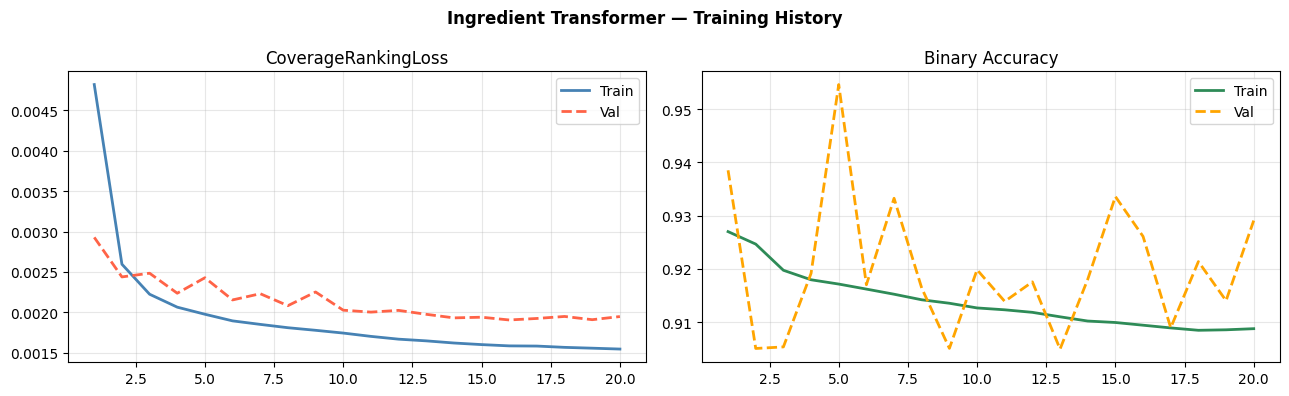

In [14]:
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Ingredient Transformer — Training History', fontweight='bold')

axes[0].plot(ep, history['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(ep, history['val_loss'],   label='Val',   color='tomato',    lw=2, ls='--')
axes[0].set_title('CoverageRankingLoss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['train_acc'], label='Train', color='seagreen', lw=2)
axes[1].plot(ep, history['val_acc'],   label='Val',   color='orange',   lw=2, ls='--')
axes[1].set_title('Binary Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()